# Сводная визуализация результатов

**Цель:** Загрузить результаты сканирования β и создать комплексный график
для итогового отчёта.

In [1]:
using DrWatson
@quickactivate

using DataFrames, CSV, Plots, Statistics

## Загрузка данных

In [2]:
println("="^60)
println("СВОДНАЯ ВИЗУАЛИЗАЦИЯ")
println("="^60)

df = CSV.read(datadir("beta_scan_all.csv"), DataFrame)

СВОДНАЯ ВИЗУАЛИЗАЦИЯ


Row,n_steps,final_rec,Ns,death_rate,Is,beta,infection_period,final_inf,detection_time,deaths,peak,reinfection_probability,seed
,Int64,Float64,String31,Float64,String15,Float64,Int64,Float64,Int64,Int64,Float64,Float64,Int64
1,100,0.000333333,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.1,14,0.0,7,0,0.000333333,0.1,42
2,100,0.00266667,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.1,14,0.0,7,0,0.002,0.1,43
3,100,0.000333333,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.1,14,0.0,7,0,0.000333333,0.1,44
4,100,0.0400976,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.2,14,0.959902,7,132,0.995285,0.1,42
5,100,0.001,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.2,14,0.0,7,0,0.001,0.1,43
6,100,0.000333333,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.2,14,0.0,7,0,0.000333333,0.1,44
7,100,0.00748503,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.3,14,0.992515,7,328,1.0,0.1,42
8,100,0.0606509,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.3,14,0.939349,7,296,0.999644,0.1,43
9,100,0.000333333,"[1000, 1000, 1000]",0.02,"[0, 0, 1]",0.3,14,0.0,7,0,0.000333333,0.1,44


## Усреднение по повторам

In [3]:
grouped = combine(
    groupby(df, [:beta]),
    :peak => mean => :mean_peak,
    :final_inf => mean => :mean_final_inf,
    :deaths => mean => :mean_deaths,
)

Row,beta,mean_peak,mean_final_inf,mean_deaths
,Float64,Float64,Float64,Float64
1,0.1,0.000888889,0.0,0.0
2,0.2,0.332206,0.319967,44.0
3,0.3,0.666659,0.643955,208.0
4,0.4,0.666889,0.629722,226.667
5,0.5,1.0,0.996625,317.667
6,0.6,1.0,0.993352,348.0
7,0.7,1.0,0.962127,361.333
8,0.8,1.0,0.946348,356.333
9,0.9,1.0,0.963478,385.667


## Создание комплексного графика

Панель 1: Пик и конечная доля

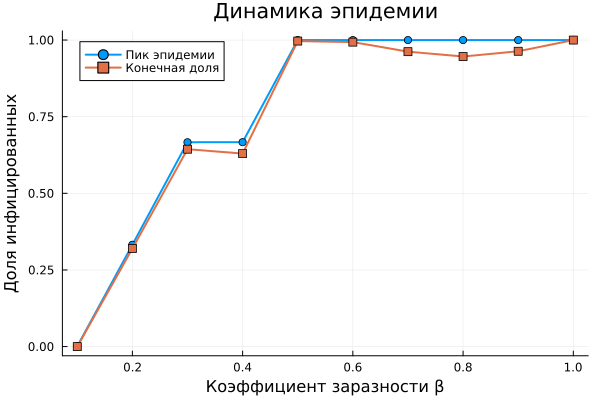

In [4]:
p1 = plot(grouped.beta, grouped.mean_peak,
          label = "Пик эпидемии",
          marker = :circle,
          linewidth = 2,
          title = "Динамика эпидемии",
          xlabel = "Коэффициент заразности β",
          ylabel = "Доля инфицированных",
          legend = :topleft)
plot!(p1, grouped.beta, grouped.mean_final_inf,
      label = "Конечная доля",
      marker = :square,
      linewidth = 2)

Панель 2: Доля умерших

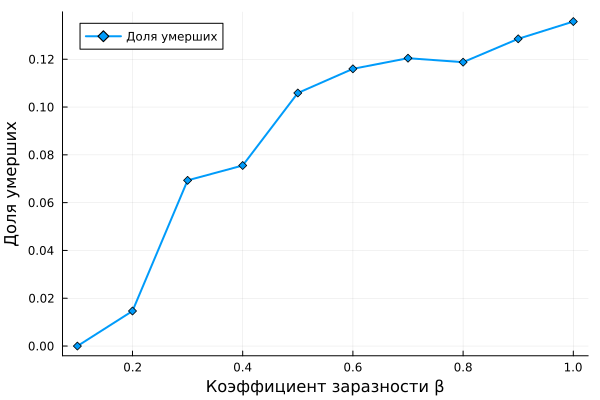

In [5]:
p2 = plot(grouped.beta, grouped.mean_deaths ./ 3000,
          label = "Доля умерших",
          marker = :diamond,
          linewidth = 2,
          xlabel = "Коэффициент заразности β",
          ylabel = "Доля умерших",
          legend = :topleft)

Объединение

In [6]:
final_plot = plot(p1, p2, layout = (2, 1), size = (800, 600))
savefig(final_plot, plotsdir("comprehensive_analysis.png"))

"/afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab04/project/plots/comprehensive_analysis.png"

## Вывод статистики

In [7]:
println("\nСводная статистика:")
println("\nβ\tПик (%)\tУмершие")
println("-"^30)
for row in eachrow(grouped)
    println("$(row.beta)\t$(round(row.mean_peak*100, digits=1))\t$(round(row.mean_deaths, digits=0))")
end

println("\n✅ Визуализация завершена!")
println("График сохранён в: ", plotsdir("comprehensive_analysis.png"))


Сводная статистика:

β	Пик (%)	Умершие
------------------------------
0.1	0.1	0.0
0.2	33.2	44.0
0.3	66.7	208.0
0.4	66.7	227.0
0.5	100.0	318.0
0.6	100.0	348.0
0.7	100.0	361.0
0.8	100.0	356.0
0.9	100.0	386.0
1.0	100.0	407.0

✅ Визуализация завершена!
График сохранён в: /afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab04/project/plots/comprehensive_analysis.png
